In [1]:
# ============================================================
# XAI CELL 1 — SETUP + VERIFY INPUT FILES
# ============================================================

import numpy as np
from pathlib import Path

DATA = Path(
    "/kaggle/input/datasets/subbhaa/"
    "bloodmnist-medmnist-dataset/bloodmnist.npz"
)

def find_file(name):
    hits = list(Path("/kaggle/input").rglob(name))
    if not hits:
        hits = list(Path("/kaggle/working").rglob(name))
    return hits[0] if hits else None

WEIGHTS = find_file("gcn_dropout_0p3_best.weights.h5")
PREDICTIONS = find_file("final_improved_gcn_test_predictions.csv")

OUT = Path("/kaggle/working/task3_xai_outputs")
FIG_DIR = OUT / "figures"
RES_DIR = OUT / "results"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

print("BloodMNIST :", DATA.exists(), DATA)
print("GCN weights:", WEIGHTS)
print("Predictions:", PREDICTIONS)

assert DATA.exists(), "BloodMNIST dataset missing."
assert WEIGHTS is not None, "Final GCN checkpoint missing."
assert PREDICTIONS is not None, "Final prediction CSV missing."

data = np.load(DATA)

print("\nTrain :", data["train_images"].shape)
print("Val   :", data["val_images"].shape)
print("Test  :", data["test_images"].shape)

print("\n✓ XAI CELL 1 COMPLETED")

BloodMNIST : True /kaggle/input/datasets/subbhaa/bloodmnist-medmnist-dataset/bloodmnist.npz
GCN weights: /kaggle/input/notebooks/jf10101001/group04-bloodmnist-task3-improvement-ablation-ipyn/task3_outputs/checkpoints/gcn_dropout_0p3_best.weights.h5
Predictions: /kaggle/input/notebooks/jf10101001/group04-bloodmnist-task3-improvement-ablation-ipyn/task3_outputs/predictions/final_improved_gcn_test_predictions.csv

Train : (11959, 28, 28, 3)
Val   : (1712, 28, 28, 3)
Test  : (3421, 28, 28, 3)

✓ XAI CELL 1 COMPLETED


In [2]:
# ============================================================
# XAI CELL 2 — LOAD FINAL GCN + SELECT XAI SAMPLES
# ============================================================

import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

IMG, NUM_CLASSES = 224, 8

CLASS_NAMES = [
    "Basophil", "Eosinophil", "Erythroblast",
    "Immature granulocytes", "Lymphocyte",
    "Monocyte", "Neutrophil", "Platelet"
]

x_test = data["test_images"]
y_test = data["test_labels"].reshape(-1).astype(int)


# ---------- 4-neighbour normalized adjacency ----------
A = np.eye(49, dtype=np.float32)

for r in range(7):
    for c in range(7):
        i = r * 7 + c
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            rr, cc = r + dr, c + dc
            if 0 <= rr < 7 and 0 <= cc < 7:
                A[i, rr * 7 + cc] = 1

D = np.diag(1 / np.sqrt(A.sum(1)))
A = (D @ A @ D).astype(np.float32)


# ---------- Original Residual GCN layer ----------
class FixedAdjacencyResidualGCNLayer(layers.Layer):

    def __init__(self, units, adjacency,
                 dropout_rate=.2, activation="relu", **kwargs):

        super().__init__(**kwargs)

        self.units = units
        self.adjacency_np = np.asarray(adjacency, np.float32)
        self.activation = tf.keras.activations.get(activation)

        self.message_dense = layers.Dense(units, use_bias=False)
        self.self_dense = layers.Dense(units, use_bias=False)
        self.norm = layers.BatchNormalization()
        self.dropout = layers.Dropout(dropout_rate)

    def build(self, input_shape):

        self.adjacency = self.add_weight(
            name="fixed_adjacency",
            shape=self.adjacency_np.shape,
            initializer=tf.keras.initializers.Constant(
                self.adjacency_np
            ),
            trainable=False
        )

        super().build(input_shape)

    def call(self, x, training=False):

        neighbour = tf.einsum(
            "ij,bjf->bif",
            self.adjacency,
            x
        )

        x = (
            self.message_dense(neighbour)
            + self.self_dense(x)
        )

        x = self.norm(x, training=training)
        x = self.activation(x)

        return self.dropout(x, training=training)


# ---------- Final architecture ----------
inp = layers.Input((IMG, IMG, 3), name="bloodmnist_image")

x = layers.Lambda(
    preprocess_input,
    name="resnet50_preprocessing"
)(inp)

backbone = ResNet50(
    input_shape=(IMG, IMG, 3),
    include_top=False,
    weights="imagenet"
)
backbone.trainable = False

feature_map = backbone(x, training=False)

x = layers.Resizing(
    7, 7,
    name="feature_map_to_graph_grid"
)(feature_map)

x = layers.Reshape(
    (49, 2048),
    name="feature_map_nodes"
)(x)

g1 = FixedAdjacencyResidualGCNLayer(
    256, A, .30,
    name="residual_gcn_1"
)(x)

g2 = FixedAdjacencyResidualGCNLayer(
    256, A, .30,
    name="residual_gcn_2"
)(g1)

x = layers.Add(
    name="gcn_residual_skip"
)([g1, g2])

x = FixedAdjacencyResidualGCNLayer(
    128, A, .30,
    name="residual_gcn_3"
)(x)

x = layers.GlobalAveragePooling1D(
    name="graph_global_average_pooling"
)(x)

x = layers.Dense(
    256,
    activation="relu",
    name="classification_dense"
)(x)

x = layers.BatchNormalization(
    name="classification_batch_norm"
)(x)

x = layers.Dropout(
    .35,
    name="classification_dropout"
)(x)

out = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="bloodmnist_classifier"
)(x)

model = Model(inp, out)

# Build + load
_ = model(tf.zeros((1, IMG, IMG, 3)), training=False)
model.load_weights(WEIGHTS)

print("✓ Final GCN loaded successfully")


# ---------- Correct + misclassified sample ----------
pred = pd.read_csv(PREDICTIONS)
pred["correct"] = pred.true_label == pred.predicted_label

c = pred[pred.correct].sort_values(
    "confidence", ascending=False
).iloc[0]

w = pred[~pred.correct].sort_values(
    "confidence", ascending=False
).iloc[0]

correct_idx = int(c.sample_index)
wrong_idx = int(w.sample_index)

selected = pd.DataFrame([
    ["Correct", correct_idx,
     CLASS_NAMES[int(c.true_label)],
     CLASS_NAMES[int(c.predicted_label)],
     c.confidence],

    ["Misclassified", wrong_idx,
     CLASS_NAMES[int(w.true_label)],
     CLASS_NAMES[int(w.predicted_label)],
     w.confidence]

], columns=[
    "Type", "Index", "True", "Predicted", "Confidence"
])

selected.to_csv(
    RES_DIR / "selected_xai_samples.csv",
    index=False
)

print("\nSELECTED XAI SAMPLES")
display(selected.round(4))

print("\n✓ XAI CELL 2 COMPLETED")

I0000 00:00:1786908658.178223      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786908658.181250      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
✓ Final GCN loaded successfully

SELECTED XAI SAMPLES


,Type,Index,True,Predicted,Confidence
0,Correct,1024,Eosinophil,Eosinophil,1.0
1,Misclassified,3126,Neutrophil,Eosinophil,1.0



✓ XAI CELL 2 COMPLETED


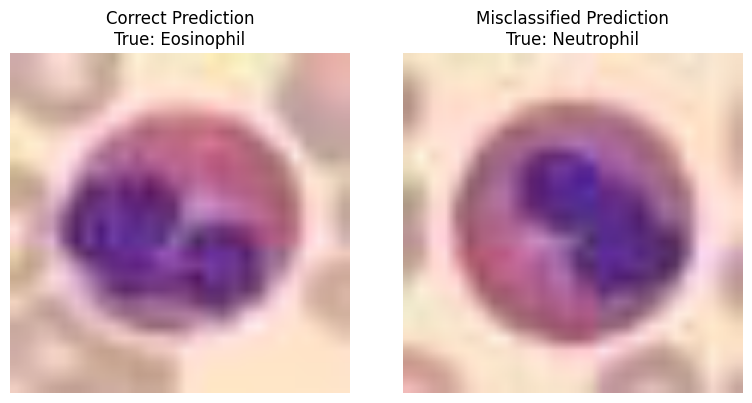

✓ Saved: /kaggle/working/task3_xai_outputs/figures/selected_correct_vs_misclassified.png
✓ XAI CELL 3 COMPLETED


In [3]:
# ============================================================
# XAI CELL 3 — VISUALIZE SELECTED SAMPLES
# ============================================================

import matplotlib.pyplot as plt
import tensorflow as tf

def show_sample(idx, title):

    img = tf.image.resize(
        x_test[idx],
        (IMG, IMG)
    ).numpy().astype("uint8")

    plt.imshow(img)
    plt.title(
        f"{title}\n"
        f"True: {CLASS_NAMES[y_test[idx]]}"
    )
    plt.axis("off")


plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
show_sample(
    correct_idx,
    "Correct Prediction"
)

plt.subplot(1, 2, 2)
show_sample(
    wrong_idx,
    "Misclassified Prediction"
)

plt.tight_layout()

sample_fig = (
    FIG_DIR
    / "selected_correct_vs_misclassified.png"
)

plt.savefig(
    sample_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", sample_fig)
print("✓ XAI CELL 3 COMPLETED")

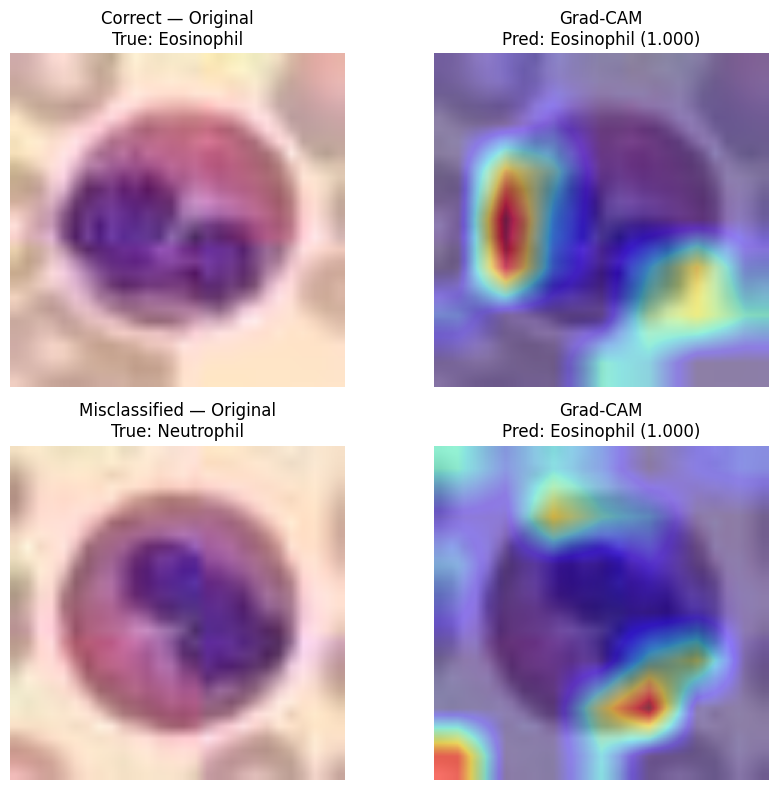

✓ Saved: /kaggle/working/task3_xai_outputs/figures/gradcam_correct_vs_misclassified.png
✓ XAI CELL 4 COMPLETED


In [4]:
# ============================================================
# XAI CELL 4 — GRAD-CAM
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model

# Model returning CNN feature map + final GCN prediction
grad_model = Model(
    model.input,
    [feature_map, model.output]
)

def make_gradcam(idx):

    img = tf.image.resize(
        x_test[idx],
        (IMG, IMG)
    )

    x = tf.expand_dims(
        tf.cast(img, tf.float32),
        0
    )

    with tf.GradientTape() as tape:

        fmap, probs = grad_model(
            x,
            training=False
        )

        pred_class = tf.argmax(probs[0])
        score = probs[0, pred_class]

    grads = tape.gradient(
        score,
        fmap
    )

    weights = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    cam = tf.reduce_sum(
        fmap[0] * weights[0],
        axis=-1
    )

    cam = tf.maximum(cam, 0)
    cam /= tf.reduce_max(cam) + 1e-8

    cam = tf.image.resize(
        cam[..., None],
        (IMG, IMG)
    ).numpy().squeeze()

    return (
        img.numpy().astype("uint8"),
        cam,
        int(pred_class),
        float(probs[0, pred_class])
    )


# Generate
correct_img, correct_cam, correct_pred, correct_conf = make_gradcam(
    correct_idx
)

wrong_img, wrong_cam, wrong_pred, wrong_conf = make_gradcam(
    wrong_idx
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    2, 2,
    figsize=(9, 8)
)

items = [
    (
        correct_img,
        correct_cam,
        correct_idx,
        correct_pred,
        correct_conf,
        "Correct"
    ),
    (
        wrong_img,
        wrong_cam,
        wrong_idx,
        wrong_pred,
        wrong_conf,
        "Misclassified"
    )
]

for r, (img, cam, idx, pred, conf, status) in enumerate(items):

    ax[r,0].imshow(img)
    ax[r,0].set_title(
        f"{status} — Original\n"
        f"True: {CLASS_NAMES[y_test[idx]]}"
    )

    ax[r,1].imshow(img)
    ax[r,1].imshow(
        cam,
        cmap="jet",
        alpha=0.45
    )

    ax[r,1].set_title(
        f"Grad-CAM\n"
        f"Pred: {CLASS_NAMES[pred]} "
        f"({conf:.3f})"
    )

    ax[r,0].axis("off")
    ax[r,1].axis("off")


plt.tight_layout()

GRADCAM_FIG = (
    FIG_DIR
    / "gradcam_correct_vs_misclassified.png"
)

plt.savefig(
    GRADCAM_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", GRADCAM_FIG)
print("✓ XAI CELL 4 COMPLETED")

Generating LIME explanations...


  0%|          | 0/500 [00:00<?, ?it/s]

I0000 00:00:1786908680.062384      71 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  0%|          | 0/500 [00:00<?, ?it/s]

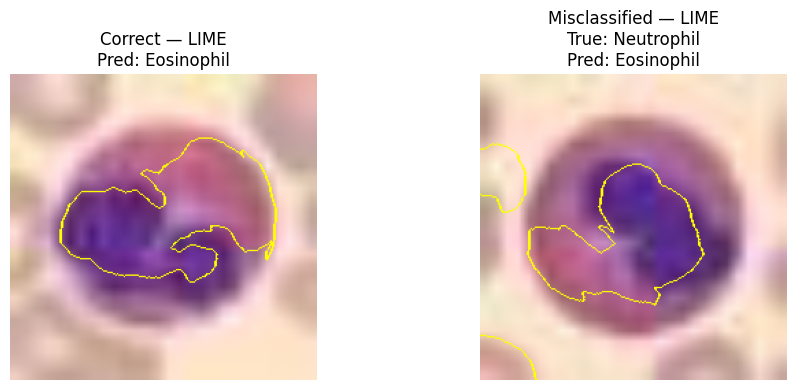

✓ Saved: /kaggle/working/task3_xai_outputs/figures/lime_correct_vs_misclassified.png
✓ XAI CELL 5 COMPLETED


In [5]:
# ============================================================
# XAI CELL 5 — LIME
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries, slic

try:
    from lime import lime_image
except ImportError:
    import sys, subprocess
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "lime"],
        check=True
    )
    from lime import lime_image


# ------------------------------------------------------------
# Prediction function
# ------------------------------------------------------------

def lime_predict(images):
    return model.predict(
        np.asarray(images, dtype=np.float32),
        batch_size=32,
        verbose=0
    )


explainer = lime_image.LimeImageExplainer(
    random_state=42
)


# ------------------------------------------------------------
# Generate one explanation
# ------------------------------------------------------------

def make_lime(idx):

    img = tf.image.resize(
        x_test[idx],
        (IMG, IMG)
    ).numpy().astype(np.uint8)

    explanation = explainer.explain_instance(
        img,
        lime_predict,
        top_labels=1,
        num_samples=500,
        segmentation_fn=lambda x: slic(
            x,
            n_segments=50,
            compactness=10,
            start_label=1
        )
    )

    pred_class = explanation.top_labels[0]

    shown, mask = explanation.get_image_and_mask(
        pred_class,
        positive_only=True,
        num_features=8,
        hide_rest=False
    )

    lime_img = mark_boundaries(
        shown / 255.0,
        mask
    )

    return lime_img, pred_class


print("Generating LIME explanations...")

lime_correct, lime_correct_pred = make_lime(
    correct_idx
)

lime_wrong, lime_wrong_pred = make_lime(
    wrong_idx
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    1, 2,
    figsize=(10, 4)
)

ax[0].imshow(lime_correct)
ax[0].set_title(
    f"Correct — LIME\n"
    f"Pred: {CLASS_NAMES[lime_correct_pred]}"
)
ax[0].axis("off")


ax[1].imshow(lime_wrong)
ax[1].set_title(
    f"Misclassified — LIME\n"
    f"True: {CLASS_NAMES[y_test[wrong_idx]]}\n"
    f"Pred: {CLASS_NAMES[lime_wrong_pred]}"
)
ax[1].axis("off")


plt.tight_layout()

LIME_FIG = (
    FIG_DIR
    / "lime_correct_vs_misclassified.png"
)

plt.savefig(
    LIME_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", LIME_FIG)
print("✓ XAI CELL 5 COMPLETED")

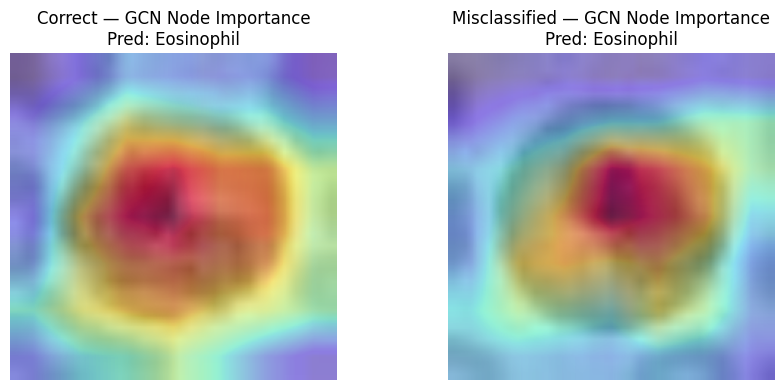

✓ Saved: /kaggle/working/task3_xai_outputs/figures/gcn_node_importance_correct_vs_misclassified.png
✓ 7×7 node importance values saved
✓ XAI CELL 6 COMPLETED


In [6]:
# ============================================================
# XAI CELL 6 — GCN NODE IMPORTANCE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model, Input

# ------------------------------------------------------------
# 1. CNN → 49 graph-node extractor
# ------------------------------------------------------------

node_extractor = Model(
    model.input,
    model.get_layer("feature_map_nodes").output
)

# ------------------------------------------------------------
# 2. Rebuild GCN head using trained layers
# ------------------------------------------------------------

node_input = Input((49, 2048))

g1 = model.get_layer("residual_gcn_1")(
    node_input, training=False
)

g2 = model.get_layer("residual_gcn_2")(
    g1, training=False
)

x = model.get_layer("gcn_residual_skip")(
    [g1, g2]
)

x = model.get_layer("residual_gcn_3")(
    x, training=False
)

x = model.get_layer(
    "graph_global_average_pooling"
)(x)

x = model.get_layer(
    "classification_dense"
)(x)

x = model.get_layer(
    "classification_batch_norm"
)(x, training=False)

x = model.get_layer(
    "classification_dropout"
)(x, training=False)

out = model.get_layer(
    "bloodmnist_classifier"
)(x)

gcn_head = Model(
    node_input,
    out
)


# ------------------------------------------------------------
# 3. Gradient × Activation node importance
# ------------------------------------------------------------

def make_node_importance(idx):

    img = tf.image.resize(
        x_test[idx],
        (IMG, IMG)
    )

    img = tf.expand_dims(
        tf.cast(img, tf.float32),
        0
    )

    nodes = node_extractor(
        img,
        training=False
    )

    with tf.GradientTape() as tape:

        tape.watch(nodes)

        probs = gcn_head(
            nodes,
            training=False
        )

        pred_class = tf.argmax(
            probs[0]
        )

        score = probs[
            0,
            pred_class
        ]

    grads = tape.gradient(
        score,
        nodes
    )

    importance = tf.reduce_mean(
        tf.abs(grads * nodes),
        axis=-1
    )[0]

    importance = tf.reshape(
        importance,
        (7, 7)
    ).numpy()

    importance = (
        importance - importance.min()
    ) / (
        importance.max()
        - importance.min()
        + 1e-8
    )

    return (
        importance,
        int(pred_class)
    )


# ------------------------------------------------------------
# 4. Generate
# ------------------------------------------------------------

node_correct, node_correct_pred = (
    make_node_importance(correct_idx)
)

node_wrong, node_wrong_pred = (
    make_node_importance(wrong_idx)
)


# ------------------------------------------------------------
# 5. Visualization
# ------------------------------------------------------------

fig, ax = plt.subplots(
    1, 2,
    figsize=(9, 4)
)

items = [
    (
        correct_idx,
        node_correct,
        node_correct_pred,
        "Correct"
    ),
    (
        wrong_idx,
        node_wrong,
        node_wrong_pred,
        "Misclassified"
    )
]

for a, (idx, importance, pred, status) in zip(ax, items):

    img = tf.image.resize(
        x_test[idx],
        (IMG, IMG)
    ).numpy().astype("uint8")

    heatmap = tf.image.resize(
        importance[..., None],
        (IMG, IMG)
    ).numpy().squeeze()

    a.imshow(img)

    a.imshow(
        heatmap,
        cmap="jet",
        alpha=0.45
    )

    a.set_title(
        f"{status} — GCN Node Importance\n"
        f"Pred: {CLASS_NAMES[pred]}"
    )

    a.axis("off")


plt.tight_layout()

NODE_FIG = (
    FIG_DIR
    / "gcn_node_importance_correct_vs_misclassified.png"
)

plt.savefig(
    NODE_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 6. Save raw 7×7 importance values
# ------------------------------------------------------------

pd.DataFrame(
    node_correct
).to_csv(
    RES_DIR / "correct_node_importance_7x7.csv",
    index=False
)

pd.DataFrame(
    node_wrong
).to_csv(
    RES_DIR / "misclassified_node_importance_7x7.csv",
    index=False
)

print("✓ Saved:", NODE_FIG)
print("✓ 7×7 node importance values saved")
print("✓ XAI CELL 6 COMPLETED")

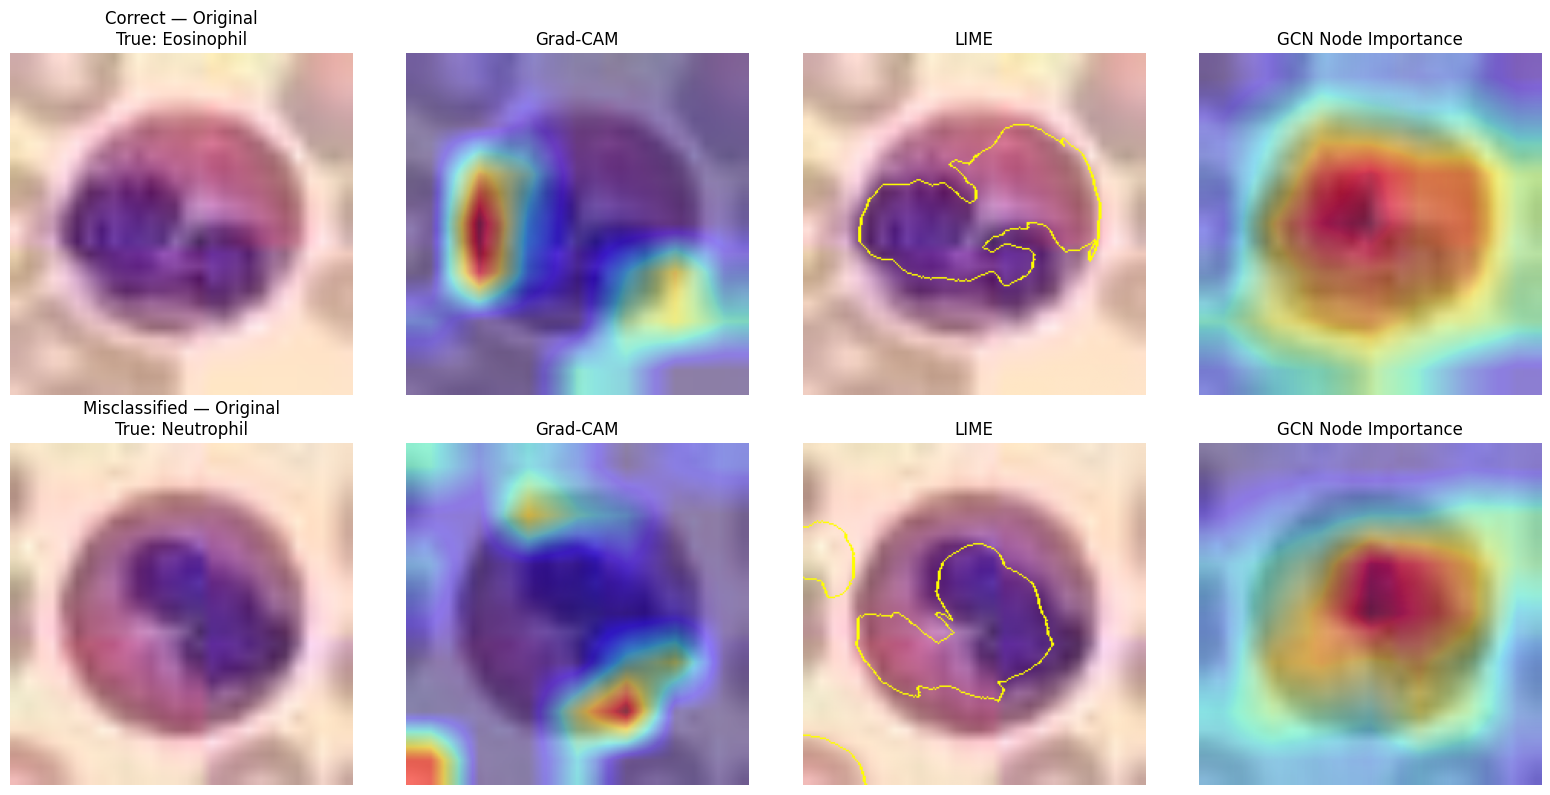

✓ Saved: /kaggle/working/task3_xai_outputs/figures/final_combined_xai_comparison.png
✓ XAI CELL 7 COMPLETED


In [7]:
# ============================================================
# XAI CELL 7 — COMBINED XAI FIGURE
# ============================================================

import matplotlib.pyplot as plt
import tensorflow as tf

fig, ax = plt.subplots(2, 4, figsize=(16, 8))

rows = [
    (correct_idx, correct_cam, lime_correct, node_correct, "Correct"),
    (wrong_idx, wrong_cam, lime_wrong, node_wrong, "Misclassified")
]

for r, (idx, cam, lime_img, node_map, status) in enumerate(rows):

    img = tf.image.resize(
        x_test[idx], (IMG, IMG)
    ).numpy().astype("uint8")

    node_heatmap = tf.image.resize(
        node_map[..., None],
        (IMG, IMG)
    ).numpy().squeeze()

    # Original
    ax[r,0].imshow(img)
    ax[r,0].set_title(
        f"{status} — Original\n"
        f"True: {CLASS_NAMES[y_test[idx]]}"
    )

    # Grad-CAM
    ax[r,1].imshow(img)
    ax[r,1].imshow(cam, cmap="jet", alpha=.45)
    ax[r,1].set_title("Grad-CAM")

    # LIME
    ax[r,2].imshow(lime_img)
    ax[r,2].set_title("LIME")

    # GCN node importance
    ax[r,3].imshow(img)
    ax[r,3].imshow(node_heatmap, cmap="jet", alpha=.45)
    ax[r,3].set_title("GCN Node Importance")

    for c in range(4):
        ax[r,c].axis("off")

plt.tight_layout()

FINAL_XAI_FIG = (
    FIG_DIR / "final_combined_xai_comparison.png"
)

plt.savefig(
    FINAL_XAI_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", FINAL_XAI_FIG)
print("✓ XAI CELL 7 COMPLETED")

In [8]:
# ============================================================
# XAI CELL 8 — FINAL SUMMARY
# ============================================================

import pandas as pd

c = selected.iloc[0]
w = selected.iloc[1]

summary_text = f"""
TASK 3 — EXPLAINABILITY SUMMARY

Correct Prediction
------------------
True Class      : {c['True']}
Predicted Class : {c['Predicted']}
Confidence      : {c['Confidence']:.4f}

Misclassified Prediction
------------------------
True Class      : {w['True']}
Predicted Class : {w['Predicted']}
Confidence      : {w['Confidence']:.4f}

Explainability Methods
----------------------
Grad-CAM:
Highlights important spatial regions from the ResNet50 feature map
that influenced the final prediction.

LIME:
Uses superpixel perturbations to show image regions that positively
supported the predicted class.

GCN Node Importance:
Shows the contribution of the 49 graph nodes derived from the 7×7
CNN feature map. Higher-intensity regions indicate graph nodes with
greater influence on the final GCN prediction.

Overall:
The correct and misclassified examples allow comparison of how the
model focuses on image regions and graph nodes during successful and
unsuccessful predictions.
""".strip()


# Save text summary
SUMMARY_PATH = (
    RES_DIR / "xai_final_report_summary.txt"
)

with open(SUMMARY_PATH, "w") as f:
    f.write(summary_text)


# Save method summary
method_df = pd.DataFrame([
    ["Grad-CAM", "CNN spatial feature importance"],
    ["LIME", "Superpixel-level image explanation"],
    ["GCN Node Importance", "Importance of 49 graph nodes"]
], columns=["Method", "Purpose"])

METHOD_PATH = (
    RES_DIR / "xai_methods_summary.csv"
)

method_df.to_csv(
    METHOD_PATH,
    index=False
)


print(summary_text)

print("\nSaved:")
print("✓", FINAL_XAI_FIG)
print("✓", SUMMARY_PATH)
print("✓", METHOD_PATH)

print("\n" + "=" * 72)
print("TASK 3 EXPLAINABILITY NOTEBOOK COMPLETE")
print("=" * 72)

print("✓ Correct prediction analyzed")
print("✓ Misclassified prediction analyzed")
print("✓ Grad-CAM completed")
print("✓ LIME completed")
print("✓ GCN node importance completed")
print("✓ Combined XAI figure saved")
print("\n✓ TASK 3 CODING FULLY COMPLETED")

TASK 3 — EXPLAINABILITY SUMMARY

Correct Prediction
------------------
True Class      : Eosinophil
Predicted Class : Eosinophil
Confidence      : 1.0000

Misclassified Prediction
------------------------
True Class      : Neutrophil
Predicted Class : Eosinophil
Confidence      : 1.0000

Explainability Methods
----------------------
Grad-CAM:
Highlights important spatial regions from the ResNet50 feature map
that influenced the final prediction.

LIME:
Uses superpixel perturbations to show image regions that positively
supported the predicted class.

GCN Node Importance:
Shows the contribution of the 49 graph nodes derived from the 7×7
CNN feature map. Higher-intensity regions indicate graph nodes with
greater influence on the final GCN prediction.

Overall:
The correct and misclassified examples allow comparison of how the
model focuses on image regions and graph nodes during successful and
unsuccessful predictions.

Saved:
✓ /kaggle/working/task3_xai_outputs/figures/final_combined_xa

In [9]:
# ============================================================
# XAI CELL 9 — ZIP ALL XAI OUTPUTS
# ============================================================

import shutil
from pathlib import Path

SOURCE = Path("/kaggle/working/task3_xai_outputs")
ZIP_NAME = "/kaggle/working/Group04_Task3_XAI"

shutil.make_archive(
    ZIP_NAME,
    "zip",
    SOURCE
)

print("✓ XAI ZIP CREATED")
print(ZIP_NAME + ".zip")

✓ XAI ZIP CREATED
/kaggle/working/Group04_Task3_XAI.zip
